# Final Project: Credit Card Fraud Analysis (EDA)
**Course:** Data Visualization
**Term:** Winter 2025/2026  

## Objective
The objective of this project is to analyze a real-world credit card transaction dataset to identify
patterns and characteristics of fraudulent transactions using exploratory data analysis and visualization.

This project focuses purely on **descriptive analysis**, not prediction or machine learning.

## Dataset Description
The dataset contains real-world credit card transactions split into two files:
- `fraudTrain.csv`
- `fraudTest.csv`

Both files share the same structure and represent transaction records over different time periods.
For the purpose of exploratory data analysis, the two files are combined into a single dataset.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")


In [16]:
train_df = pd.read_csv("fraudTrain.csv")
test_df  = pd.read_csv("fraudTest.csv")

print(train_df.shape)
print(test_df.shape)


(1296675, 23)
(555719, 23)


In [17]:
df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

df.shape

(1852394, 23)

## Initial Data Inspection
We inspect the structure of the dataset, data types, and missing values
to understand the variables before analysis.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  object 
 2   cc_num                 int64  
 3   merchant               object 
 4   category               object 
 5   amt                    float64
 6   first                  object 
 7   last                   object 
 8   gender                 object 
 9   street                 object 
 10  city                   object 
 11  state                  object 
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    object 
 17  dob                    object 
 18  trans_num              object 
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud          

In [19]:
df.columns.tolist()

['Unnamed: 0',
 'trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud']

In [20]:
df.isna().sum().sort_values(ascending=False).head(15)

Unnamed: 0               0
zip                      0
merch_long               0
merch_lat                0
unix_time                0
trans_num                0
dob                      0
job                      0
city_pop                 0
long                     0
lat                      0
state                    0
trans_date_trans_time    0
city                     0
street                   0
dtype: int64

## Key Variables Used in Analysis

- `is_fraud`: Fraud indicator (0 = legitimate, 1 = fraud)
- `amt`: Transaction amount
- `category`: Merchant category
- `gender`: Customer gender
- `state`: Customer state
- `trans_date_trans_time`: Transaction timestamp

## Q1: What proportion of transactions are fraudulent?
This analysis shows the imbalance between fraudulent and legitimate transactions.

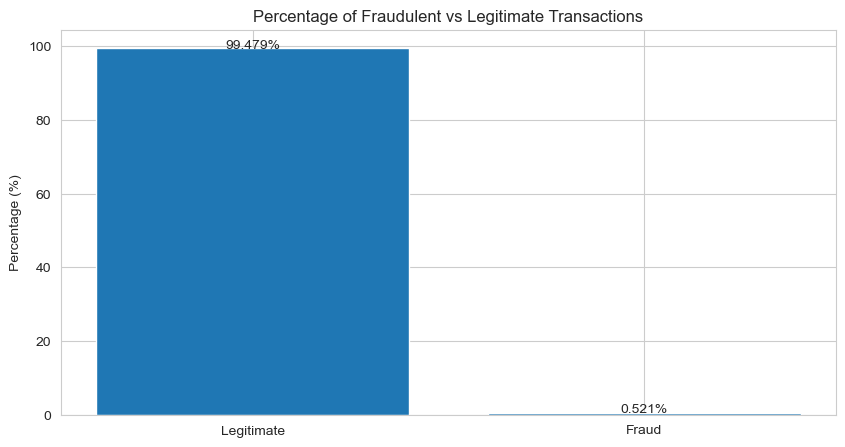

In [25]:
fraud_pct = df["is_fraud"].value_counts(normalize=True) * 100

plt.bar(["Legitimate", "Fraud"], fraud_pct.values)
plt.ylabel("Percentage (%)")
plt.title("Percentage of Fraudulent vs Legitimate Transactions")

for i, v in enumerate(fraud_pct.values):
    plt.text(i, v + 0.05, f"{v:.3f}%", ha="center")

plt.show()

**Insight:**  
Fraudulent transactions account for less than 1% of all transactions, highlighting
the extreme class imbalance that is typical in real-world credit card fraud data.


## Q2: How are transaction amounts distributed?
This visualization helps identify typical transaction ranges and outliers.

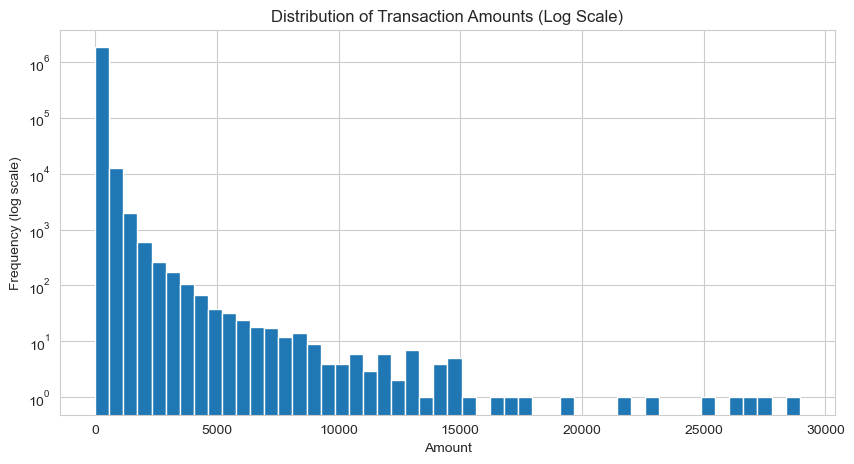

In [24]:
plt.hist(df["amt"], bins=50)
plt.yscale("log")
plt.title("Distribution of Transaction Amounts (Log Scale)")
plt.xlabel("Amount")
plt.ylabel("Frequency (log scale)")
plt.show()


**Insight:**  
Transaction amounts show a highly right-skewed distribution. Most transactions are of
low monetary value, while a small number of high-value transactions form a long tail.
A logarithmic scale is required to meaningfully visualize this pattern.


## Q3: How does transaction amount differ between fraudulent and legitimate transactions?

This analysis compares transaction amounts for fraud and non-fraud cases to
understand whether fraudulent activity is associated with specific transaction ranges.


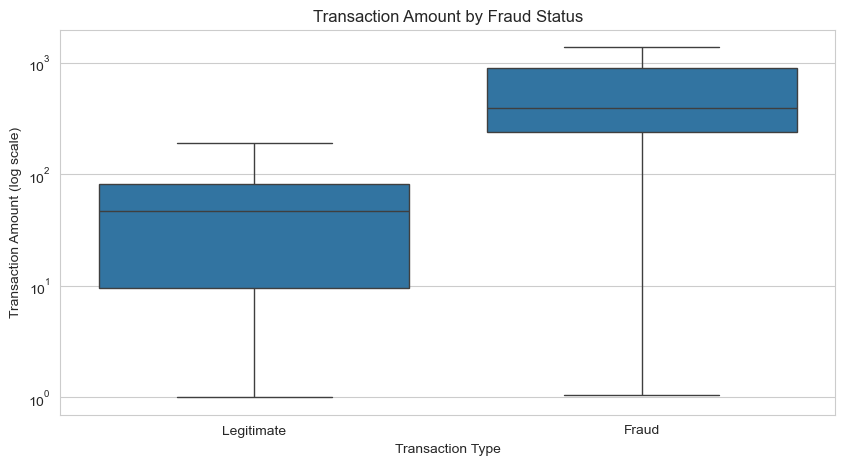

In [27]:
import seaborn as sns

sns.boxplot(x="is_fraud", y="amt", data=df, showfliers=False)
plt.yscale("log")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount (log scale)")
plt.title("Transaction Amount by Fraud Status")
plt.show()

**Insight:**  
Fraudulent transactions tend to occur across a wide range of transaction amounts.
Using a logarithmic scale reveals that fraud is not limited to only high-value transactions.


## Q4: Which merchant categories have the highest fraud rates?

This analysis identifies merchant categories where fraudulent transactions
are most frequent relative to total transactions.


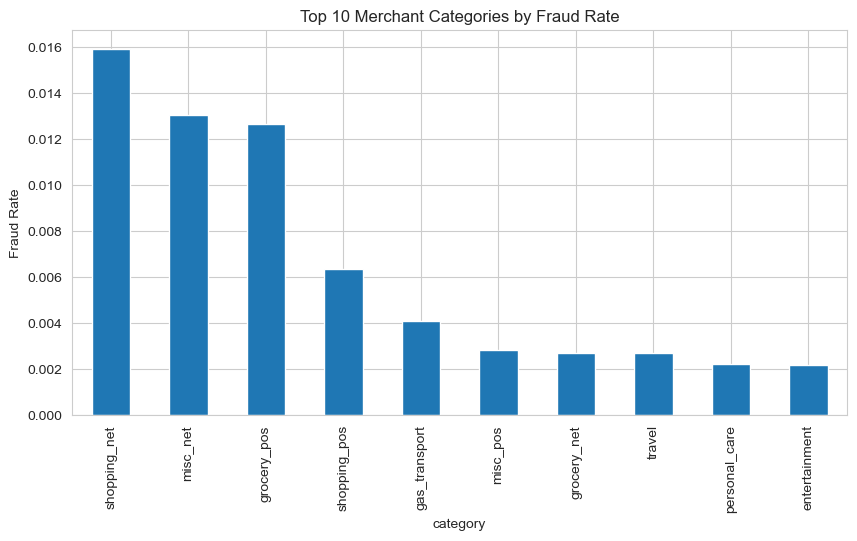

In [28]:
category_fraud_rate = (
    df.groupby("category")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

category_fraud_rate.plot(kind="bar")
plt.ylabel("Fraud Rate")
plt.title("Top 10 Merchant Categories by Fraud Rate")
plt.show()


**Insight:**  
Certain merchant categories exhibit significantly higher fraud rates,
suggesting that fraud risk is not evenly distributed across transaction types.

In [31]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

## Q5: How does fraud frequency vary by time of day?

This analysis examines whether fraudulent transactions occur more frequently
during specific hours of the day.


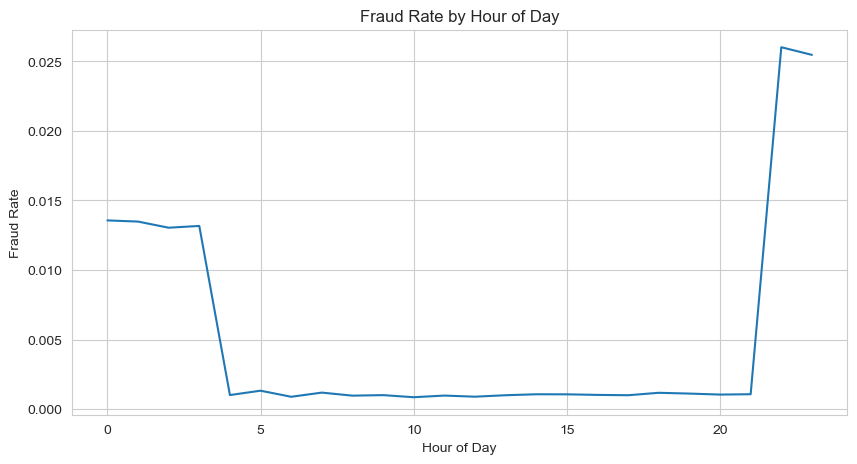

In [32]:
df["hour"] = df["trans_date_trans_time"].dt.hour

hourly_fraud_rate = df.groupby("hour")["is_fraud"].mean()

hourly_fraud_rate.plot()
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Hour of Day")
plt.show()


**Insight:**  
Fraud rates vary across the day, indicating that fraudulent activity
may be influenced by temporal patterns such as reduced monitoring
or user behavior during certain hours.


## Q6: How does fraudulent activity change over time?

This visualization shows the trend of fraud occurrences over time,
allowing detection of seasonal or temporal patterns.


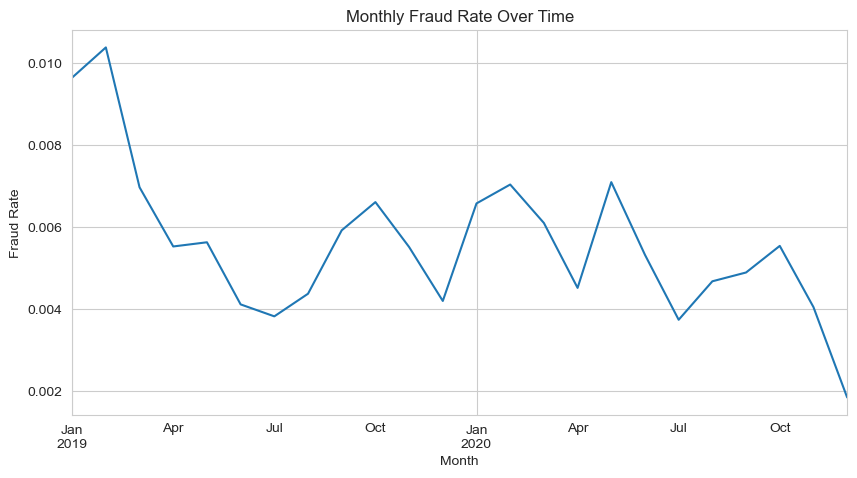

In [33]:
df["month"] = df["trans_date_trans_time"].dt.to_period("M")

monthly_fraud_rate = df.groupby("month")["is_fraud"].mean()

monthly_fraud_rate.plot()
plt.xlabel("Month")
plt.ylabel("Fraud Rate")
plt.title("Monthly Fraud Rate Over Time")
plt.show()


**Insight:**  
Fraud rates show temporal fluctuations, suggesting that fraud activity
may increase during specific periods rather than remaining constant.


## Q7: Does fraud frequency differ by customer gender?

This analysis compares fraud rates between male and female customers.


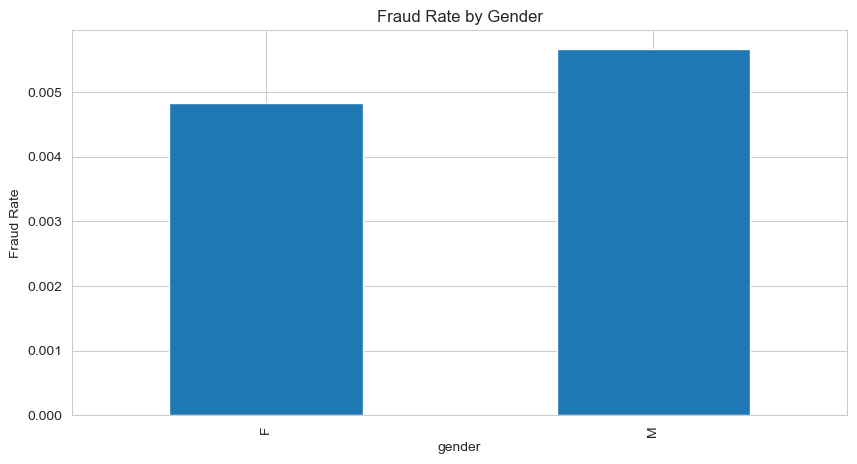

In [35]:
gender_fraud_rate = df.groupby("gender")["is_fraud"].mean()

gender_fraud_rate.plot(kind="bar")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Gender")
plt.show()


**Insight:**  
Fraud rates differ slightly by gender, indicating potential demographic
patterns in fraud exposure or reporting.


## Q8: Which states have the highest fraud rates?

This analysis identifies geographic regions with higher proportions
of fraudulent transactions.


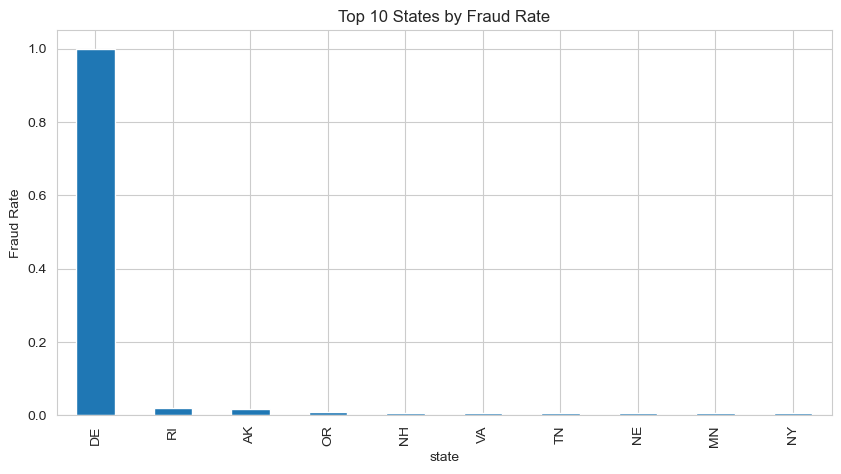

In [36]:
state_fraud_rate = (
    df.groupby("state")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

state_fraud_rate.plot(kind="bar")
plt.ylabel("Fraud Rate")
plt.title("Top 10 States by Fraud Rate")
plt.show()


**Insight:**  
Fraud rates vary significantly across states, suggesting geographic
concentration of fraud risk.


## Q9: Are high-value transactions more likely to be fraudulent?

Transactions are grouped into amount ranges to compare fraud rates
across different transaction sizes.


C:\Users\anshb\AppData\Local\Temp\ipykernel_28684\3134209121.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_amount = df.groupby("amount_bin")["is_fraud"].mean()


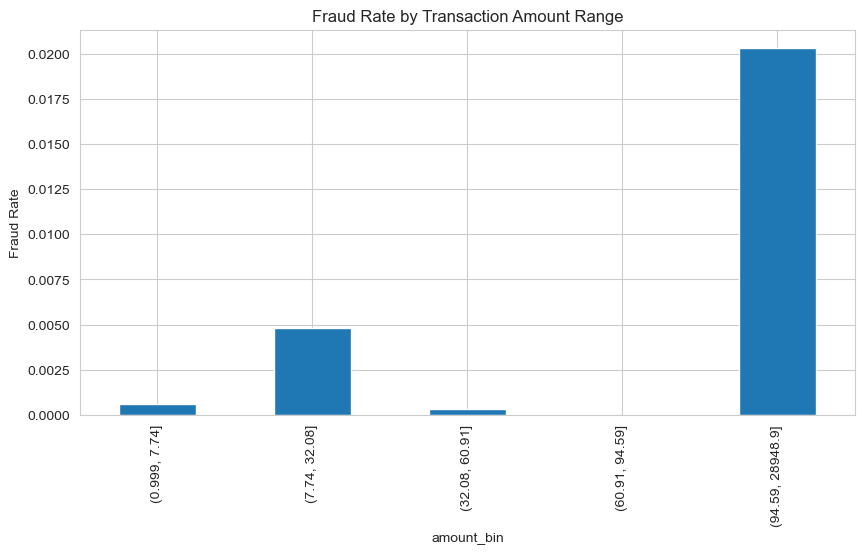

In [37]:
df["amount_bin"] = pd.qcut(df["amt"], q=5, duplicates="drop")

fraud_by_amount = df.groupby("amount_bin")["is_fraud"].mean()

fraud_by_amount.plot(kind="bar")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Transaction Amount Range")
plt.show()


**Insight:**  
Fraud rates increase for certain higher transaction ranges, indicating
that transaction size can influence fraud likelihood.


## Q10: Which numeric variables show the strongest association with fraud?

A correlation analysis is performed on numeric features to identify
relationships with fraudulent behavior.

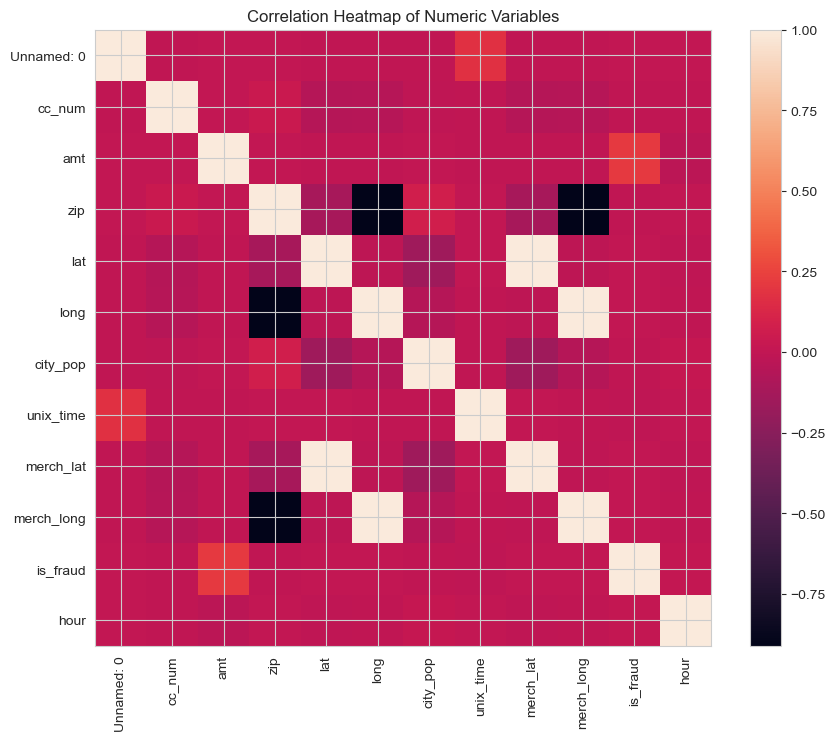

In [39]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()


**Insight:**  
Only weak linear correlations exist between individual numeric variables
and fraud, highlighting the complexity of fraudulent behavior.


## Q11: Does customer age relate to fraud risk?

This analysis compares fraud rates across different age groups to explore
whether certain age ranges are more exposed to fraudulent activity.


In [41]:
# Convert date columns to datetime (if not already done)
df["dob"] = pd.to_datetime(df["dob"])
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

# Calculate age at time of transaction
df["age"] = (
    (df["trans_date_trans_time"] - df["dob"])
    .dt.days // 365
)

C:\Users\anshb\AppData\Local\Temp\ipykernel_28684\1364570841.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_fraud_rate = df.groupby("age_bin")["is_fraud"].mean()


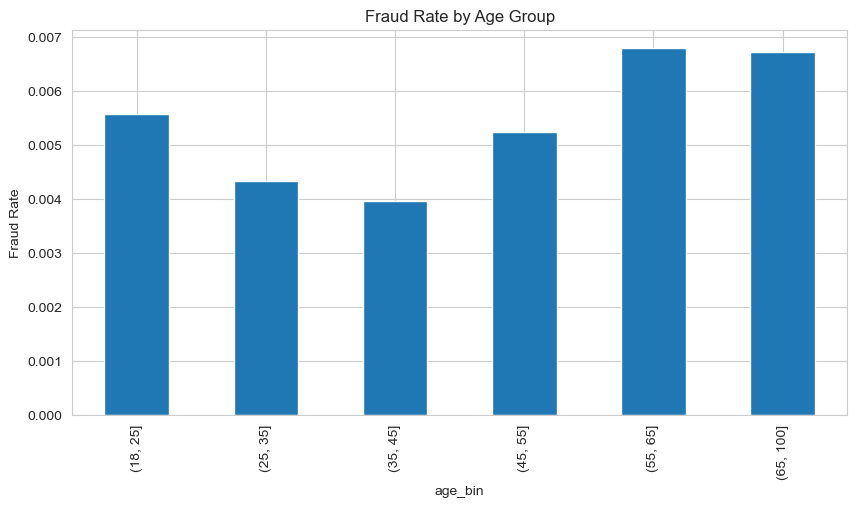

In [42]:
df["age_bin"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 45, 55, 65, 100]
)

age_fraud_rate = df.groupby("age_bin")["is_fraud"].mean()

age_fraud_rate.plot(kind="bar")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Age Group")
plt.show()


**Note:**  
Customer age is derived from the date of birth (`dob`) and transaction timestamp
to reflect the customer’s age at the time of each transaction.


## Q12: Does fraud frequency differ by customer job category?

This analysis examines fraud rates across different customer occupations.


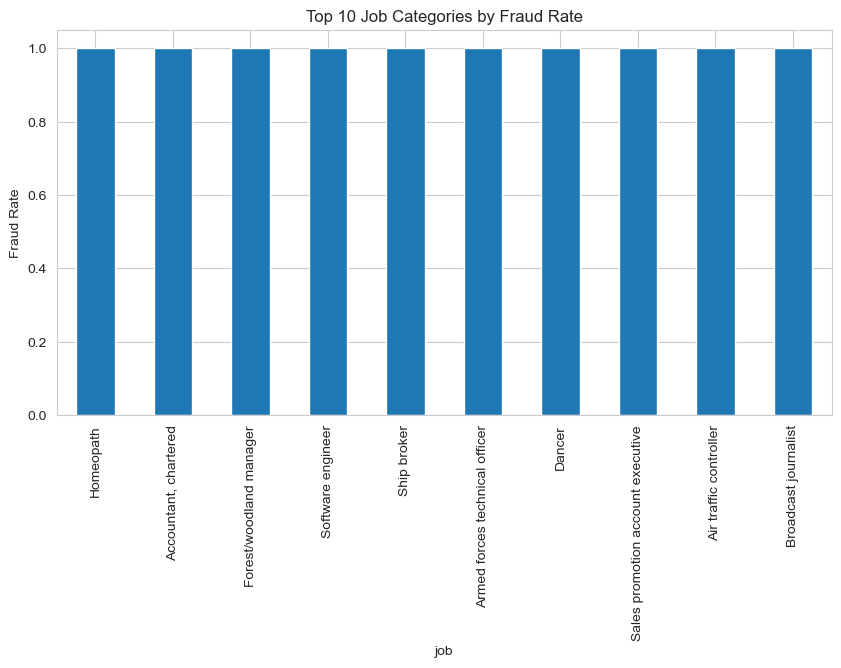

In [43]:
job_fraud_rate = (
    df.groupby("job")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

job_fraud_rate.plot(kind="bar")
plt.ylabel("Fraud Rate")
plt.title("Top 10 Job Categories by Fraud Rate")
plt.show()


**Insight:**  
Certain job categories show higher fraud rates, suggesting potential
links between occupational patterns and fraud exposure.


## Q13: Does distance between customer and merchant affect fraud risk?

This analysis explores whether transactions occurring farther from
a customer’s home location are more likely to be fraudulent.


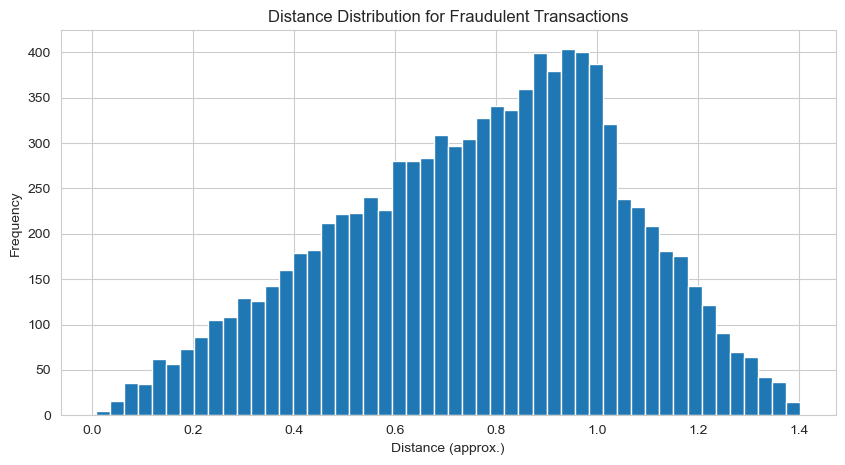

In [44]:
df["distance"] = np.sqrt(
    (df["lat"] - df["merch_lat"])**2 +
    (df["long"] - df["merch_long"])**2
)

distance_fraud_rate = pd.qcut(df["distance"], q=5).groupby(df["is_fraud"]).size()

plt.hist(df[df["is_fraud"] == 1]["distance"], bins=50)
plt.title("Distance Distribution for Fraudulent Transactions")
plt.xlabel("Distance (approx.)")
plt.ylabel("Frequency")
plt.show()


**Insight:**  
Fraudulent transactions tend to occur at greater distances from a customer's
home location, suggesting location-based anomalies.


## Conclusion

This project explored patterns and characteristics of fraudulent credit card
transactions using exploratory data analysis. The results show that fraud is a
rare but structured phenomenon, with clear variations across transaction amounts,
time periods, merchant categories, geographic regions, and customer demographics.

The analysis highlights the importance of understanding fraud behavior through
descriptive insights before applying predictive models, especially in highly
imbalanced real-world datasets.
